In [39]:
from trectools import TrecQrel
from  nltk.metrics import agreement
import pandas as pd
import json
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np

def qrel_eval(qrels_a, qrels_b, dataset, measure):
    a = TrecQrel(f'../data/msmarco-passage-{dataset}/qrels/{qrels_a}.qrels.txt')
    b = TrecQrel(f'../data/msmarco-passage-{dataset}/qrels/{qrels_b}.qrels.txt')

    # trectools uses q0 for the join, but this field is not uniformly set
    a.qrels_data['q0'] = '0'
    b.qrels_data['q0'] = '0'

    data = []
    for _, i in a.qrels_data.iterrows():
        data.append(("a", f'{i["query"]}-{i["docid"]}', i['rel']))

    for _, i in b.qrels_data.iterrows():
        data.append(("b", f'{i["query"]}-{i["docid"]}', i['rel']))

    atask = agreement.AnnotationTask(data=data)

    return {'multi_kappa': atask.multi_kappa(), 'agreement': a.check_agreement(b)}[measure]


def correlation(qrels_a, qrels_b, year, method):
    eval_scores = json.load(open('evaluation-scores-per-system.json', 'r'))
    systems = eval_scores[qrels_a][year].keys()
    df = []
    for system in systems:
        df.append({'system': system, 'qrels_a': eval_scores[qrels_a][year][system]['ndcg@10'], 'qrels_b': eval_scores[qrels_b][year][system]['ndcg@10']})

    df = pd.DataFrame(df)

    return df[['qrels_a', 'qrels_b']].corr(method=method).iloc[0]['qrels_b']


def compare_qrel_files(qrels_a, qrels_b):
    ret = []
    for year in ['trec-dl-2019-judged', 'trec-dl-2020-judged', 'v2.1-trec-rag-2024-judged']:
        ret.append(qrel_eval(qrels_a, qrels_b, year, 'multi_kappa'))
        ret.append(qrel_eval(qrels_a, qrels_b, year, 'agreement'))
        if 'trec-dl' in year:
            ret.append(correlation(qrels_a, qrels_b, year.split('-')[2][2:], 'kendall'))
            ret.append(correlation(qrels_a, qrels_b, year.split('-')[2][2:], 'spearman'))


    ret = ["{:.3f}".format(i) for i in ret]
    return ' & '.join(ret)


In [2]:
def table():
    return """\\begin{tabular}{@{}l@{\\hspace{3\\tabcolsep}}cccc@{\\hspace{3\\tabcolsep}}cccc@{\\hspace{3\\tabcolsep}}cc@{}}
\\toprule
\\bfseries Annotator     &   \\multicolumn{4}{c@{\\hspace{3\\tabcolsep}}}{\\bfseries DL 19}  & \\multicolumn{4}{c@{\\hspace{3\\tabcolsep}}}{\\bfseries DL 20} & \\multicolumn{2}{c@{\\hspace{3\\tabcolsep}}}{\\bfseries RAG 24} \\\\
\\cmidrule(r@{2\\tabcolsep}){2-3}
\\cmidrule(r@{2\\tabcolsep}){4-5}
\\cmidrule{6-7}

& $\\kappa$ & Agr. & $\\tau$ & $\\rho$ & $\\kappa$ & Agr. & $\\tau$ & $\\rho$ & $\\kappa$ & Agr. \\\\

\\midrule

Claude-3-haiku & """ + compare_qrel_files('trec', 'AnthropicLLM-claude-3-haiku-20240307-umbrella_zeroshot_basic') + """ \\\\


Claude-3-sonnet & """ + compare_qrel_files('trec', 'AnthropicLLM-claude-3-sonnet-20240229-umbrella_zeroshot_basic') + """ \\\\

Llama-3 & """ + compare_qrel_files('trec', 'LiteLLM-llama3-umbrella_zeroshot_basic') + """ \\\\

Llama-3.1 & """ + compare_qrel_files('trec', 'LiteLLM-llama3.1-umbrella_zeroshot_basic') + """ \\\\

Gemini-1.5-flash & """ + compare_qrel_files('trec', 'GeminiGPT-gemini-1.5-flash-umbrella_zeroshot_basic') + """ \\\\

Gemini-1.5-flash-8b & """ + compare_qrel_files('trec', 'GeminiGPT-gemini-1.5-flash-8b-umbrella_zeroshot_basic') + """ \\\\

GPT-4o & """ + compare_qrel_files('trec', 'OpenAiGPT-gpt-4o-umbrella_zeroshot_basic') + """ \\\\

GPT-4o-mini & """ + compare_qrel_files('trec', 'OpenAiGPT-gpt-4o-mini-umbrella_zeroshot_basic') + """ \\\\


\\bottomrule

\\end{tabular}"""

print(table())

KeyboardInterrupt: 

In [3]:
MODELS = [
    'AnthropicLLM-claude-3-haiku-20240307-umbrella_zeroshot_basic',
    'AnthropicLLM-claude-3-sonnet-20240229-umbrella_zeroshot_basic',
    'LiteLLM-llama3-umbrella_zeroshot_basic',
    'LiteLLM-llama3.1-umbrella_zeroshot_basic',
    'OpenAiGPT-gpt-4o-umbrella_zeroshot_basic',
    'OpenAiGPT-gpt-4o-mini-umbrella_zeroshot_basic',
    'GeminiGPT-gemini-1.5-flash-umbrella_zeroshot_basic',
    'GeminiGPT-gemini-1.5-flash-8b-umbrella_zeroshot_basic',
    'trec'
]

MODEL_TO_NAME = {
    'AnthropicLLM-claude-3-haiku-20240307-umbrella_zeroshot_basic': 'Claude-3-haiku',
    'AnthropicLLM-claude-3-sonnet-20240229-umbrella_zeroshot_basic': 'Claude-3-sonnet',
    'LiteLLM-llama3-umbrella_zeroshot_basic': 'Llama-3',
    'LiteLLM-llama3.1-umbrella_zeroshot_basic': 'Llama-3.1',
    'GeminiGPT-gemini-1.5-flash-umbrella_zeroshot_basic': 'Gemini-1.5-flash',
    'GeminiGPT-gemini-1.5-flash-8b-umbrella_zeroshot_basic': 'Gemini-1.5-flash-8b',
    'OpenAiGPT-gpt-4o-umbrella_zeroshot_basic': 'GPT-4o',
    'OpenAiGPT-gpt-4o-mini-umbrella_zeroshot_basic': 'GPT-4o-mini',
    'trec': 'Official'
}


In [4]:
def pairwise_correlations(year, method):
    df = []
    total = len(MODELS) * (len(MODELS) - 1) // 2
    pg = tqdm(total=total)
    for a in range(len(MODELS)):
        for b in range(len(MODELS)):
            if b > a:
                continue
            model_a, model_b = MODELS[a], MODELS[b]
            df.append({'model_a': MODEL_TO_NAME[model_a], 'model_b': MODEL_TO_NAME[model_b], method: qrel_eval(model_a, model_b, year, method)})
            pg.update(1)
    return pd.DataFrame(df)

In [7]:
df19_agreement = pairwise_correlations('trec-dl-2019-judged', 'agreement')
df20_agreement = pairwise_correlations('trec-dl-2020-judged', 'agreement')
df24_agreement = pairwise_correlations('v2.1-trec-rag-2024-judged', 'agreement')

df19_multi_kappa = pairwise_correlations('trec-dl-2019-judged', 'multi_kappa')
df20_multi_kappa = pairwise_correlations('trec-dl-2020-judged', 'multi_kappa')
df24_multi_kappa = pairwise_correlations('v2.1-trec-rag-2024-judged', 'multi_kappa')

45it [00:41,  1.08it/s]                        
45it [00:51,  1.15s/it]                        
45it [01:30,  2.02s/it]                        
45it [00:41,  1.10it/s]                        
45it [00:47,  1.05s/it]                        
45it [01:19,  1.76s/it]                        


In [14]:
df19_agreement["dataset"] = "dl-19"
df19_agreement["measure"] = "jaccard"
df20_agreement["dataset"] = "dl-20"
df20_agreement["measure"] = "jaccard"
df24_agreement["dataset"] = "rag-24"
df24_agreement["measure"] = "jaccard"

df19_multi_kappa["dataset"] = "dl-19"
df19_multi_kappa["measure"] = "kappa"
df20_multi_kappa["dataset"] = "dl-20"
df20_multi_kappa["measure"] = "kappa"
df24_multi_kappa["dataset"] = "rag-24"
df24_multi_kappa["measure"] = "kappa"

df = pd.concat(
    [
        df19_agreement.rename({"agreement": "value"}, axis=1),
        df20_agreement.rename({"agreement": "value"}, axis=1),
        df24_agreement.rename({"agreement": "value"}, axis=1),
        df19_multi_kappa.rename({"multi_kappa": "value"}, axis=1),
        df20_multi_kappa.rename({"multi_kappa": "value"}, axis=1),
        df24_multi_kappa.rename({"multi_kappa": "value"}, axis=1),
    ]
)
# df = df.loc[df["model_a"] != df["model_b"]]
df["family_a"] = df["model_a"].str.split("-").str[0]
df["family_b"] = df["model_b"].str.split("-").str[0]
df["same_family"] = df["family_a"] == df["family_b"]
df

,model_a,model_b,value,dataset,measure,family_a,family_b,same_family
0,Claude-3-haiku,Claude-3-haiku,1.000000,dl-19,jaccard,Claude,Claude,True
1,Claude-3-sonnet,Claude-3-haiku,0.587257,dl-19,jaccard,Claude,Claude,True
2,Claude-3-sonnet,Claude-3-sonnet,1.000000,dl-19,jaccard,Claude,Claude,True
3,Llama-3,Claude-3-haiku,0.545032,dl-19,jaccard,Llama,Claude,False
4,Llama-3,Claude-3-sonnet,0.534341,dl-19,jaccard,Llama,Claude,False
...,...,...,...,...,...,...,...,...
40,Official,GPT-4o,0.226570,rag-24,kappa,Official,GPT,False
41,Official,GPT-4o-mini,0.170923,rag-24,kappa,Official,GPT,False
42,Official,Gemini-1.5-flash,0.175275,rag-24,kappa,Official,Gemini,False
43,Official,Gemini-1.5-flash-8b,0.179128,rag-24,kappa,Official,Gemini,False


In [10]:
text_width = 506.295  # pt
column_width = 241.14749  # pt

def set_size(width, fraction=1):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float
            Document textwidth or columnwidth in pts
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy

    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio

    fig_dim = (fig_width_in, fig_height_in)

    return fig_dim

print(set_size(text_width))
print(set_size(column_width))

(7.00560398505604, 4.329701374486343)
(3.3367578524975787, 2.062229765071612)


In [86]:
tex_fonts = {
    # Use LaTeX to write all text
    "text.usetex": False,
    "font.family": "sans",
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 12,
    "font.size": 12,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
}

plt.rcParams.update(tex_fonts)

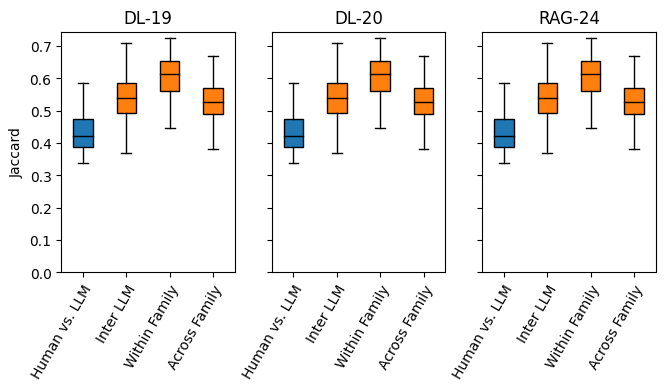

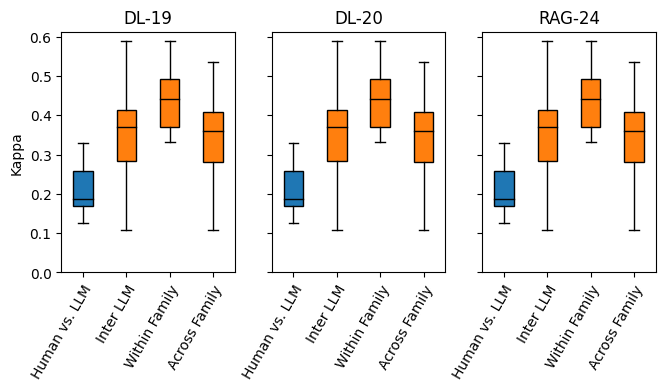

In [44]:
filters = {
    "Human vs. LLM": df["model_a"] == "Official",
    "Inter LLM": df["model_a"] != "Official",
    "Within Family": (df["model_a"] != "Official") & (df["same_family"]),
    "Across Family": (df["model_a"] != "Official") & (~df["same_family"]),
}
measure = "jaccard"
datasets = ["dl-19", "dl-20", "rag-24"]
colors = ["#1f77b4", "#ff7f0e"]
for measure in ["jaccard", "kappa"]:
    fig, axs = plt.subplots(1, len(datasets), figsize=(3.336 * 2, 1.5 * 2), sharey=True)
    fig.tight_layout()
    for idx, (dataset, ax) in enumerate(zip(datasets, axs)):
        if idx == 0:
            ax.set_ylabel(measure.capitalize())

        data = [
            df.loc[f & (df["measure"] == measure) & (df["model_a"] != df["model_b"]), "value"] for f in filters.values()
        ]
        bplot = ax.boxplot(data, showfliers=False, patch_artist=True, medianprops=dict(color="black"))
        for b_idx, patch in enumerate(bplot["boxes"]):
            patch.set_facecolor(colors[min(b_idx, 1)])
        ax.set_title(dataset.upper())
        ax.set_xticklabels(filters.keys(), rotation=60, ha="right", rotation_mode="anchor")
        ax.set_ylim(0, None)
    # fig.set_tight_layout()
    fig.savefig(f"{measure}-boxplot.pdf", bbox_inches="tight")

In [53]:
df.loc[df["model_a"] != "Official"].pivot_table(index="model_a", columns=["model_b", "measure"], values="value")

model_b             Claude-3-haiku           Claude-3-sonnet             
measure                    jaccard     kappa         jaccard     kappa   
model_a                                                                  
Claude-3-haiku            1.000000  1.000000             NaN       NaN  \
Claude-3-sonnet           0.560851  0.405394        1.000000  1.000000   
GPT-4o                    0.502325  0.324250        0.506430  0.326587   
GPT-4o-mini               0.516860  0.346946        0.521392  0.347027   
Gemini-1.5-flash          0.540954  0.376246        0.532027  0.354625   
Gemini-1.5-flash-8b       0.414128  0.207662        0.423935  0.212131   
Llama-3                   0.539514  0.377323        0.520980  0.339858   
Llama-3.1                 0.501409  0.327066        0.491850  0.298475   

model_b                GPT-4o           GPT-4o-mini             
measure               jaccard     kappa     jaccard     kappa   
model_a                                                         
Claude-3-haiku            NaN       NaN         NaN       NaN  \
Claude-3-sonnet           NaN       NaN         NaN       NaN   
GPT-4o               1.000000  1.000000         NaN       NaN   
GPT-4o-mini          0.696882  0.546228    1.000000  1.000000   
Gemini-1.5-flash     0.628195  0.467801    0.644427  0.486166   
Gemini-1.5-flash-8b  0.521150  0.323878    0.493301  0.295052   
Llama-3                   NaN       NaN         NaN       NaN   
Llama-3.1                 NaN       NaN         NaN       NaN   

model_b             Gemini-1.5-flash          Gemini-1.5-flash-8b         
measure                      jaccard    kappa             jaccard kappa   
model_a                                                                   
Claude-3-haiku                   NaN      NaN                 NaN   NaN  \
Claude-3-sonnet                  NaN      NaN                 NaN   NaN   
GPT-4o                           NaN      NaN                 NaN   NaN   
GPT-4o-mini                      NaN      NaN                 NaN   NaN   
Gemini-1.5-flash            1.000000  1.00000                 NaN   NaN   
Gemini-1.5-flash-8b         0.519191  0.30211                 1.0   1.0   
Llama-3                          NaN      NaN                 NaN   NaN   
Llama-3.1                        NaN      NaN                 NaN   NaN   

model_b               Llama-3           Llama-3.1            
measure               jaccard     kappa   jaccard     kappa  
model_a                                                      
Claude-3-haiku            NaN       NaN       NaN       NaN  
Claude-3-sonnet           NaN       NaN       NaN       NaN  
GPT-4o               0.524692  0.347418  0.534235  0.357399  
GPT-4o-mini          0.551496  0.378948  0.552372  0.373466  
Gemini-1.5-flash     0.628210  0.457312  0.616974  0.433590  
Gemini-1.5-flash-8b  0.478143  0.238524  0.471012  0.225577  
Llama-3              1.000000  1.000000       NaN       NaN  
Llama-3.1            0.645276  0.466340  1.000000  1.000000

In [52]:
df.loc[df["model_a"] != "Official"].groupby(["measure", "model_a", "model_b"])["value"].mean().to_frame().loc["jaccard"]

value
model_a             model_b                      
Claude-3-haiku      Claude-3-haiku       1.000000
Claude-3-sonnet     Claude-3-haiku       0.560851
                    Claude-3-sonnet      1.000000
GPT-4o              Claude-3-haiku       0.502325
                    Claude-3-sonnet      0.506430
                    GPT-4o               1.000000
                    Llama-3              0.524692
                    Llama-3.1            0.534235
GPT-4o-mini         Claude-3-haiku       0.516860
                    Claude-3-sonnet      0.521392
                    GPT-4o               0.696882
                    GPT-4o-mini          1.000000
                    Llama-3              0.551496
                    Llama-3.1            0.552372
Gemini-1.5-flash    Claude-3-haiku       0.540954
                    Claude-3-sonnet      0.532027
                    GPT-4o               0.628195
                    GPT-4o-mini          0.644427
                    Gemini-1.5-flash     1.000000
                    Llama-3              0.628210
                    Llama-3.1            0.616974
Gemini-1.5-flash-8b Claude-3-haiku       0.414128
                    Claude-3-sonnet      0.423935
                    GPT-4o               0.521150
                    GPT-4o-mini          0.493301
                    Gemini-1.5-flash     0.519191
                    Gemini-1.5-flash-8b  1.000000
                    Llama-3              0.478143
                    Llama-3.1            0.471012
Llama-3             Claude-3-haiku       0.539514
                    Claude-3-sonnet      0.520980
                    Llama-3              1.000000
Llama-3.1           Claude-3-haiku       0.501409
                    Claude-3-sonnet      0.491850
                    Llama-3              0.645276
                    Llama-3.1            1.000000

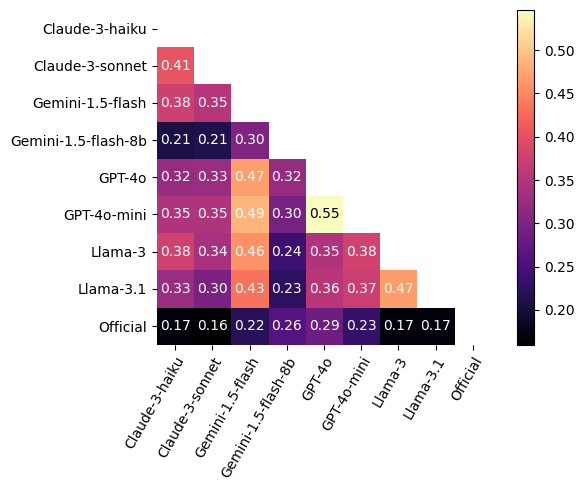

In [86]:
models = [
    "Claude-3-haiku",
    "Claude-3-sonnet",
    "Gemini-1.5-flash",
    "Gemini-1.5-flash-8b",
    "GPT-4o",
    "GPT-4o-mini",
    "Llama-3",
    "Llama-3.1",
    "Official",
]
sorted(models)

macro_avg = df.groupby(["measure", "model_a", "model_b"])["value"].mean().to_frame().loc["kappa"]
mirrored = macro_avg.copy()
mirrored.index.rename({"model_a": "model_b", "model_b": "model_a"}, inplace=True)
mirrored = mirrored.reorder_levels(["model_a", "model_b"])
macro_avg = pd.concat([macro_avg, mirrored], axis=0)
macro_avg = macro_avg.pivot_table(index="model_a", columns="model_b", values="value").loc[models, models]
macro_avg.values[np.triu(np.ones(macro_avg.shape), 0) == 1] = np.nan

fig, ax = plt.subplots(1, 1, figsize=(3.336 * 2, 5))
cbar = ax.matshow(macro_avg, cmap="magma")
fig.colorbar(cbar, ax=ax)
for i in range(len(models)):
    for j in range(len(models)):
        value = macro_avg.values[i, j]
        if value > 0.5:
            color = "black"
        else:
            color = "white"
        text = ax.text(j, i, f"{value:.2f}", color=color, ha="center", va="center")

ax.set_xticks(range(len(models)))
ax.set_yticks(range(len(models)))
ax.set_xticklabels(models, rotation=60, ha="right", rotation_mode="anchor")
ax.tick_params(axis="x", bottom=True, top=False, labeltop=False, labelbottom=True)
ax.set_yticklabels(models)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)
fig.tight_layout()
fig.savefig("kappa-matrix-with-official.pdf", bbox_inches="tight")

In [ ]:
def agreement_stats(df, v, dataset):
    ret = []
    for _, i in df[(df['model_a'] != df['model_b']) & (df['model_a'] == 'Official')].iterrows():
        ret.append({'Type': 'Human vs. LLM', 'value': i[v]})

    for _, i in df[(df['model_a'] != df['model_b']) & (df['model_a'] != 'Official')].iterrows():
        ret.append({'Type': 'LLM vs. LLM', 'value': i[v]})

    ret = pd.DataFrame(ret)
    ret['measure'] = v
    ret['Dataset'] = 'DL-' + dataset
    return ret

df = pd.concat([
    agreement_stats(df19_agreement, 'agreement', '19'),
    agreement_stats(df20_agreement, 'agreement', '20'),
    agreement_stats(df24_agreement, 'agreement', '24'),
    agreement_stats(df19_multi_kappa, 'multi_kappa', '19'),
    agreement_stats(df20_multi_kappa, 'multi_kappa', '20'),
    agreement_stats(df24_multi_kappa, 'multi_kappa', '24'),
])

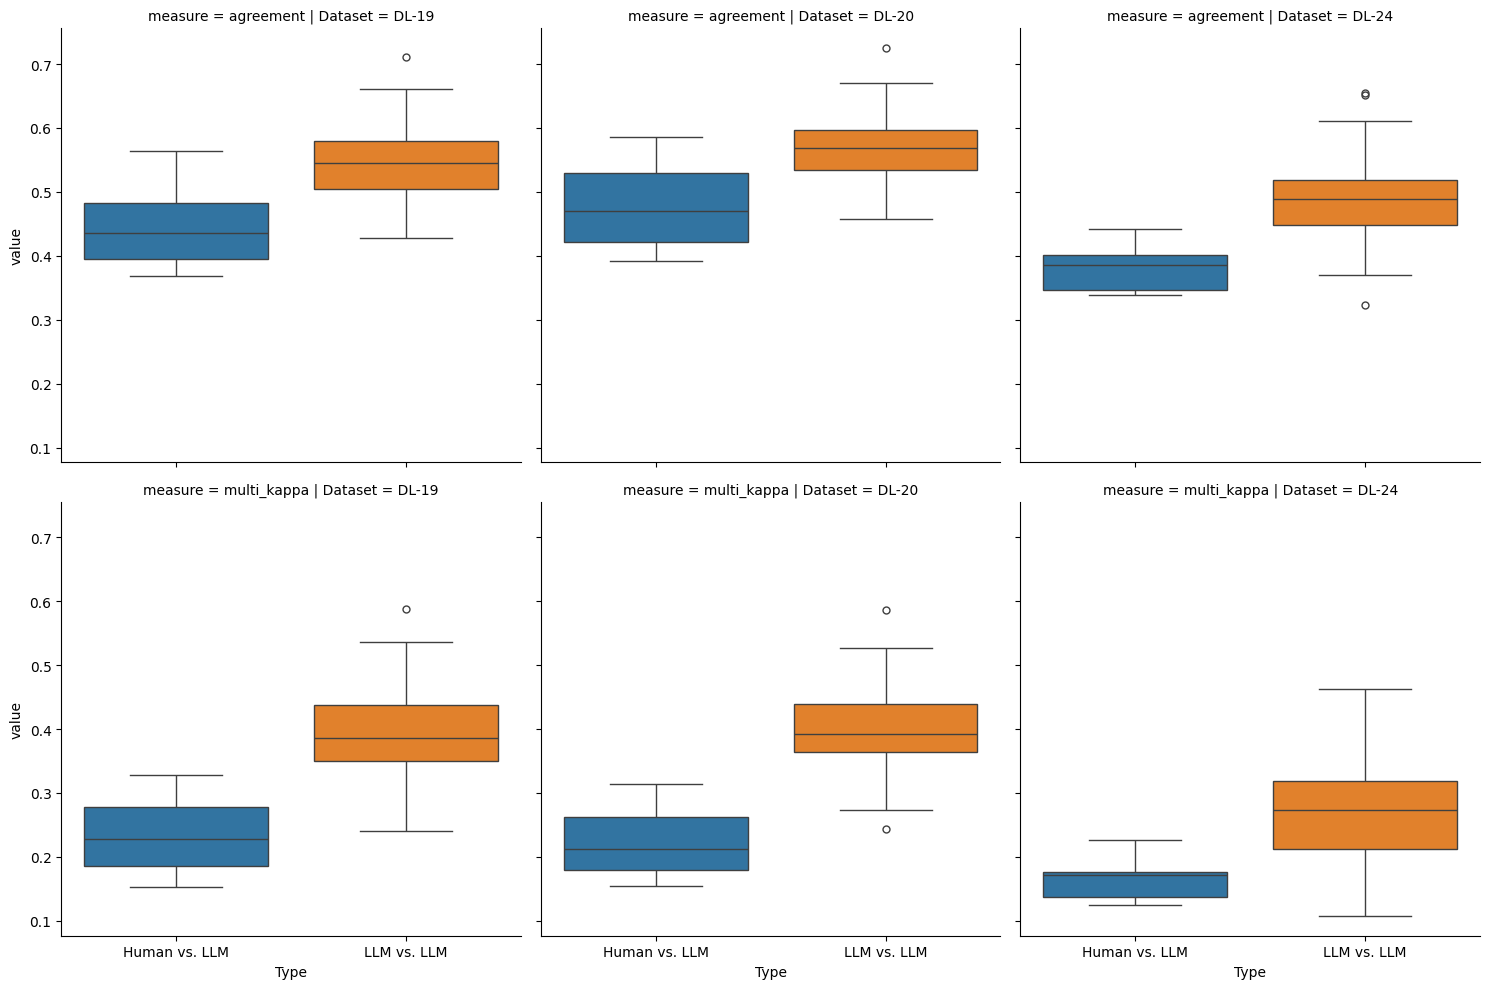

In [18]:
import seaborn as sns

sns.catplot(data=df, x='Type', y='value', hue='Type', col='Dataset', row='measure', kind='box').savefig(f'agreement-overview.pdf', bbox_inches='tight')